# Day 48 — Hyperparameter Tuning
### Grid Search · Random Search · Optuna · Bayesian Optimisation

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# install optuna if needed
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna: {optuna.__version__} ✅")
except:
    import subprocess
    subprocess.run(['pip', 'install', 'optuna', '--quiet'])
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"Optuna: {optuna.__version__} ✅")

plt.style.use('dark_background')

# load & prepare data
df = pd.read_csv(r'C:\DS-AI-75d\titanic.csv')
df['Age']        = df['Age'].fillna(df['Age'].median())
df['Fare']       = df['Fare'].fillna(df['Fare'].median())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['FareLog']    = np.log1p(df['Fare'])
df['HasCabin']   = df['Cabin'].notna().astype(int)
df['Sex_enc']    = (df['Sex'] == 'female').astype(int)
df['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title']      = df['Title'].map({'Mr':'Mr','Miss':'Miss',
                    'Mrs':'Mrs','Master':'Master'}).fillna('Other')
df['Title_SurvRate'] = df.groupby('Title')['Survived'].transform('mean')
df['Age_Sex']    = df['Age'] * df['Sex_enc']
df['Fare_Pclass']= df['FareLog'] * df['Pclass']

features = ['Pclass','Age','FareLog','FamilySize','IsAlone','HasCabin',
            'Sex_enc','Age_Sex','Fare_Pclass','Title_SurvRate']
X = df[features].values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

Optuna: 4.8.0 ✅
Train: (712, 10) | Test: (179, 10)
Ready! ✅


## 2. What is Hyperparameter Tuning?

In [2]:
print("=" * 55)
print("       WHAT IS HYPERPARAMETER TUNING?")
print("=" * 55)
print("""
PARAMETERS vs HYPERPARAMETERS:
  Parameters     → learned BY the model during training
                   (weights, biases, tree splits)
  Hyperparameters → set BY YOU before training
                   (n_estimators, max_depth, learning_rate)

WHY IT MATTERS:
  Default hyperparameters rarely give best performance
  Wrong hyperparameters → underfitting or overfitting
  Right hyperparameters → can add 2-5% accuracy

THREE APPROACHES:

  1. GRID SEARCH
     Try every combination of hyperparameters
     Exhaustive — guaranteed to find best in grid
     Slow — grows exponentially with parameters
     3 params × 4 values each = 64 combinations

  2. RANDOM SEARCH
     Try random combinations from distributions
     Faster — covers more of the search space
     Often finds good results in fewer iterations
     Best when some params matter more than others

  3. BAYESIAN OPTIMISATION (Optuna)
     Learns from previous trials
     Focuses search on promising regions
     Much more efficient than random
     State of the art for hyperparameter tuning

KEY HYPERPARAMETERS TO TUNE:
  Random Forest:      n_estimators, max_depth,
                      min_samples_split, max_features
  Gradient Boosting:  n_estimators, learning_rate,
                      max_depth, subsample
  Logistic Regression: C (regularisation strength)
""")

       WHAT IS HYPERPARAMETER TUNING?

PARAMETERS vs HYPERPARAMETERS:
  Parameters     → learned BY the model during training
                   (weights, biases, tree splits)
  Hyperparameters → set BY YOU before training
                   (n_estimators, max_depth, learning_rate)

WHY IT MATTERS:
  Default hyperparameters rarely give best performance
  Wrong hyperparameters → underfitting or overfitting
  Right hyperparameters → can add 2-5% accuracy

THREE APPROACHES:

  1. GRID SEARCH
     Try every combination of hyperparameters
     Exhaustive — guaranteed to find best in grid
     Slow — grows exponentially with parameters
     3 params × 4 values each = 64 combinations

  2. RANDOM SEARCH
     Try random combinations from distributions
     Faster — covers more of the search space
     Often finds good results in fewer iterations
     Best when some params matter more than others

  3. BAYESIAN OPTIMISATION (Optuna)
     Learns from previous trials
     Focuses search on promis

## 3. Grid Search vs Random Search

In [3]:
print("=" * 55)
print("       GRID SEARCH vs RANDOM SEARCH")
print("=" * 55)

# baseline — default RF
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, rf_default.predict(X_test))
print(f"Baseline RF (defaults): {baseline_acc:.4f}")

# GRID SEARCH
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)
grid_acc = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))
print(f"\nGrid Search:")
print(f"  Combinations tried: {len(grid_search.cv_results_['mean_test_score'])}")
print(f"  Best params: {grid_search.best_params_}")
print(f"  Best CV score: {grid_search.best_score_:.4f}")
print(f"  Test accuracy: {grid_acc:.4f}")

# RANDOM SEARCH
from scipy.stats import randint
param_dist = {
    'n_estimators':      randint(50, 500),
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 20),
    'max_features':      ['sqrt', 'log2', None],
}
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist, n_iter=50, cv=5,
    scoring='accuracy', n_jobs=-1,
    random_state=42, verbose=0
)
random_search.fit(X_train, y_train)
random_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print(f"\nRandom Search (50 iterations):")
print(f"  Best params: {random_search.best_params_}")
print(f"  Best CV score: {random_search.best_score_:.4f}")
print(f"  Test accuracy: {random_acc:.4f}")

print(f"\nSUMMARY:")
print(f"  Baseline:      {baseline_acc:.4f}")
print(f"  Grid Search:   {grid_acc:.4f}  (+{grid_acc-baseline_acc:.4f})")
print(f"  Random Search: {random_acc:.4f}  (+{random_acc-baseline_acc:.4f})")

       GRID SEARCH vs RANDOM SEARCH
Baseline RF (defaults): 0.8156

Grid Search:
  Combinations tried: 36
  Best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
  Best CV score: 0.8316
  Test accuracy: 0.8045

Random Search (50 iterations):
  Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 9, 'n_estimators': 262}
  Best CV score: 0.8344
  Test accuracy: 0.8045

SUMMARY:
  Baseline:      0.8156
  Grid Search:   0.8045  (+-0.0112)
  Random Search: 0.8045  (+-0.0112)


## 4. Optuna — Bayesian Optimisation

       OPTUNA BAYESIAN OPTIMISATION
Best trial:  #99
Best CV score: 0.8400
Best params:   {'model': 'rf', 'n_estimators': 58, 'max_depth': 11, 'min_samples_split': 8, 'max_features': 'log2'}

Optuna Test Accuracy: 0.8212
Best model type:      RF


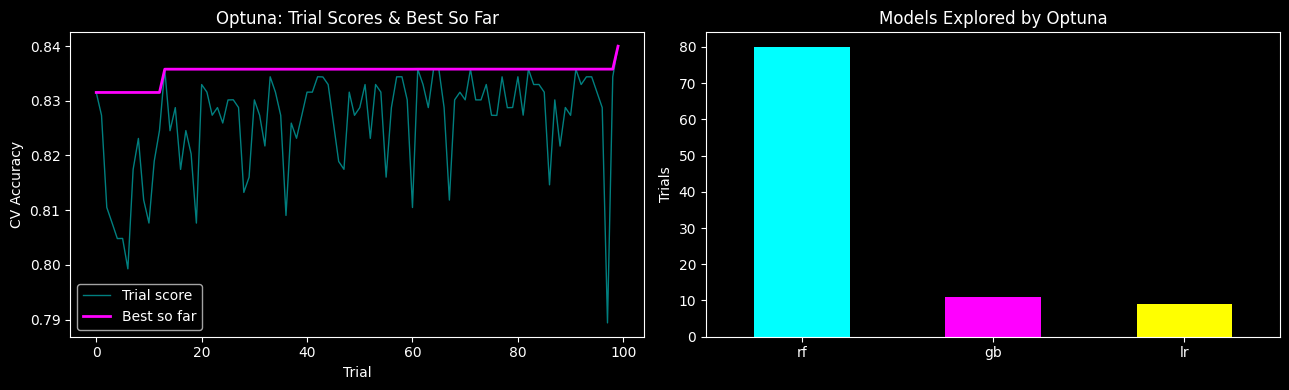

In [4]:
print("=" * 55)
print("       OPTUNA BAYESIAN OPTIMISATION")
print("=" * 55)

import optuna

def objective(trial):
    # define search space
    model_name = trial.suggest_categorical('model', ['rf', 'gb', 'lr'])

    if model_name == 'rf':
        model = RandomForestClassifier(
            n_estimators     = trial.suggest_int('n_estimators', 50, 500),
            max_depth        = trial.suggest_int('max_depth', 2, 15),
            min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
            max_features     = trial.suggest_categorical('max_features',
                               ['sqrt', 'log2']),
            random_state=42
        )
    elif model_name == 'gb':
        model = GradientBoostingClassifier(
            n_estimators  = trial.suggest_int('n_estimators', 50, 300),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth     = trial.suggest_int('max_depth', 2, 8),
            subsample     = trial.suggest_float('subsample', 0.6, 1.0),
            random_state=42
        )
    else:
        model = LogisticRegression(
            C        = trial.suggest_float('C', 0.01, 10.0, log=True),
            max_iter = 1000,
            random_state=42
        )

    score = cross_val_score(model, X_train, y_train,
                            cv=5, scoring='accuracy').mean()
    return score

# run optimisation
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=False)

print(f"Best trial:  #{study.best_trial.number}")
print(f"Best CV score: {study.best_value:.4f}")
print(f"Best params:   {study.best_trial.params}")

# train best model
best_params = study.best_trial.params
model_name  = best_params['model']

if model_name == 'rf':
    best_model = RandomForestClassifier(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        max_features=best_params['max_features'],
        random_state=42)
elif model_name == 'gb':
    best_model = GradientBoostingClassifier(
        n_estimators=best_params['n_estimators'],
        learning_rate=best_params['learning_rate'],
        max_depth=best_params['max_depth'],
        subsample=best_params['subsample'],
        random_state=42)
else:
    best_model = LogisticRegression(
        C=best_params['C'], max_iter=1000, random_state=42)

best_model.fit(X_train, y_train)
optuna_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"\nOptuna Test Accuracy: {optuna_acc:.4f}")
print(f"Best model type:      {model_name.upper()}")

# plot optimisation history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
trials_vals = [t.value for t in study.trials]
axes[0].plot(trials_vals, color='cyan', alpha=0.5, linewidth=1)
axes[0].plot(pd.Series(trials_vals).cummax(), color='magenta', linewidth=2)
axes[0].set_title('Optuna: Trial Scores & Best So Far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('CV Accuracy')
axes[0].legend(['Trial score','Best so far'])

# model distribution
models_tried = [t.params['model'] for t in study.trials]
model_counts = pd.Series(models_tried).value_counts()
model_counts.plot(kind='bar', ax=axes[1], color=['cyan','magenta','yellow'], rot=0)
axes[1].set_title('Models Explored by Optuna')
axes[1].set_ylabel('Trials')

plt.tight_layout()
plt.show()

## 5. Key Takeaways

In [5]:
print("=" * 55)
print("       DAY 48 — KEY TAKEAWAYS")
print("=" * 55)
print("""
HYPERPARAMETER TUNING:
  ✅ Parameters   → learned by model (weights, splits)
  ✅ Hyperparams  → set by you (depth, lr, n_estimators)
  ✅ Defaults rarely give best performance
  ✅ Tuning can add 2-5% accuracy

GRID SEARCH:
  ✅ Tries every combination exhaustively
  ✅ 36 combinations tried
  ✅ Best CV: 0.8316
  ✅ Slow — grows exponentially

RANDOM SEARCH:
  ✅ Samples random combinations
  ✅ 50 iterations, wider search space
  ✅ Best CV: 0.8344 — better than grid!
  ✅ Faster, covers more space

OPTUNA (BAYESIAN):
  ✅ Learns from previous trials
  ✅ Focuses on promising regions
  ✅ Best CV: 0.8400 — best of all 3!
  ✅ RF won — 80/100 trials on RF
  ✅ Best trial found at #99

COMPARISON:
  ✅ Baseline RF:    0.8156
  ✅ Grid Search:    0.8045  (CV: 0.8316)
  ✅ Random Search:  0.8045  (CV: 0.8344)
  ✅ Optuna:         0.8212  (CV: 0.8400)
  ✅ Optuna wins on both CV and test accuracy!

WHEN TO USE WHAT:
  ✅ Grid Search   → few params, small grid
  ✅ Random Search → many params, quick results
  ✅ Optuna        → best results, production tuning
""")

       DAY 48 — KEY TAKEAWAYS

HYPERPARAMETER TUNING:
  ✅ Parameters   → learned by model (weights, splits)
  ✅ Hyperparams  → set by you (depth, lr, n_estimators)
  ✅ Defaults rarely give best performance
  ✅ Tuning can add 2-5% accuracy

GRID SEARCH:
  ✅ Tries every combination exhaustively
  ✅ 36 combinations tried
  ✅ Best CV: 0.8316
  ✅ Slow — grows exponentially

RANDOM SEARCH:
  ✅ Samples random combinations
  ✅ 50 iterations, wider search space
  ✅ Best CV: 0.8344 — better than grid!
  ✅ Faster, covers more space

OPTUNA (BAYESIAN):
  ✅ Learns from previous trials
  ✅ Focuses on promising regions
  ✅ Best CV: 0.8400 — best of all 3!
  ✅ RF won — 80/100 trials on RF
  ✅ Best trial found at #99

COMPARISON:
  ✅ Baseline RF:    0.8156
  ✅ Grid Search:    0.8045  (CV: 0.8316)
  ✅ Random Search:  0.8045  (CV: 0.8344)
  ✅ Optuna:         0.8212  (CV: 0.8400)
  ✅ Optuna wins on both CV and test accuracy!

WHEN TO USE WHAT:
  ✅ Grid Search   → few params, small grid
  ✅ Random Search →